In [53]:
# 24i-6517
# Lab02

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = sns.load_dataset("tips")
sns.set_palette("Set3")

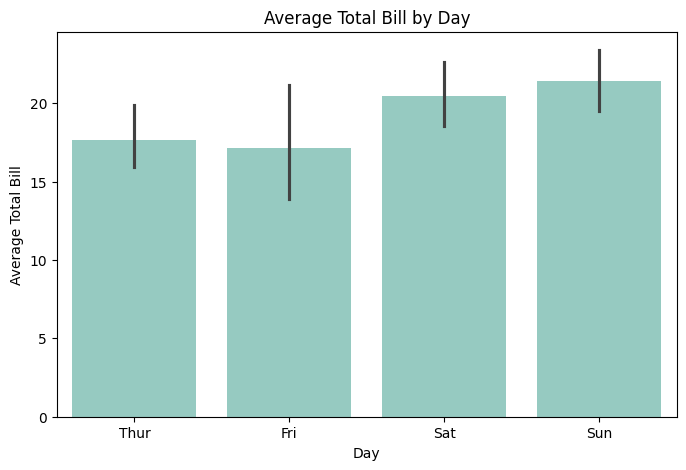

In [54]:
# Q1
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="day", y="total_bill")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.title("Average Total Bill by Day")
plt.show()

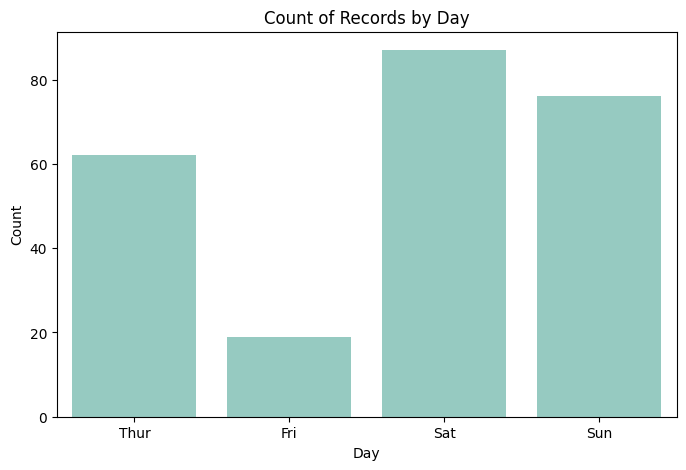

In [55]:
# Q2
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="day", order=["Thur", "Fri", "Sat", "Sun"])
plt.xlabel("Day")
plt.ylabel("Count")
plt.title("Count of Records by Day")
plt.show()

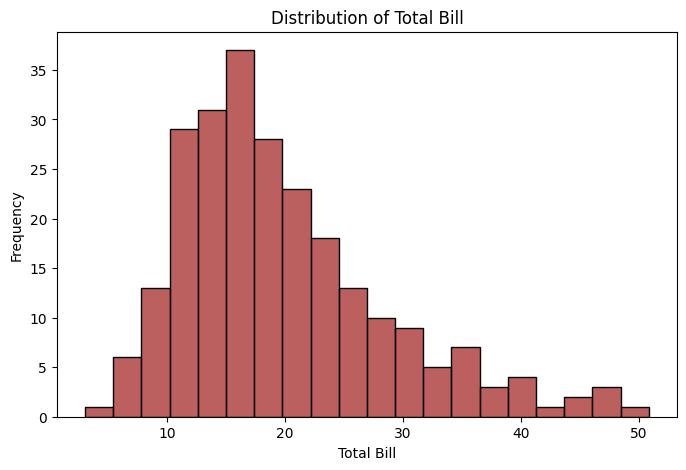

In [71]:
# Q3
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="total_bill", bins=20,color = "brown")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.title("Distribution of Total Bill")
plt.show()

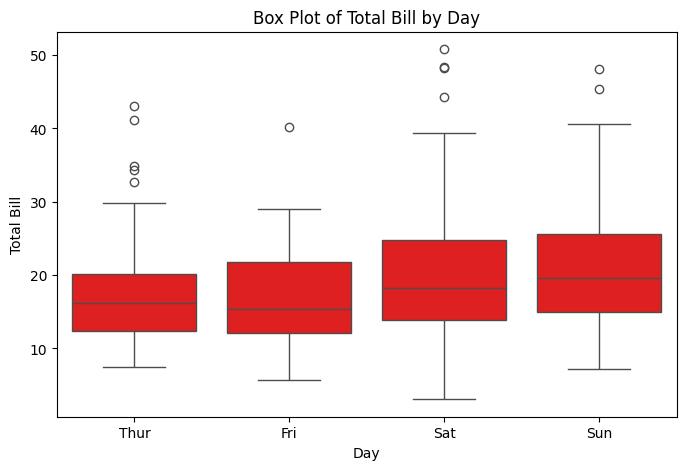

In [57]:
# Q4
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="day", y="total_bill", order=["Thur", "Fri", "Sat", "Sun"],color = "red")
plt.xlabel("Day")
plt.ylabel("Total Bill")
plt.title("Box Plot of Total Bill by Day")
plt.show()

In [58]:
# Q5
Q1 = df["total_bill"].quantile(0.25)
Q3 = df["total_bill"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df["total_bill"] < lower) | (df["total_bill"] > upper)]
print(len(outliers))

9


In [59]:
# Q6
df["zscore"] = stats.zscore(df["total_bill"])
outliers_z = df[df["zscore"].abs() > 3]
print(len(outliers_z))

4


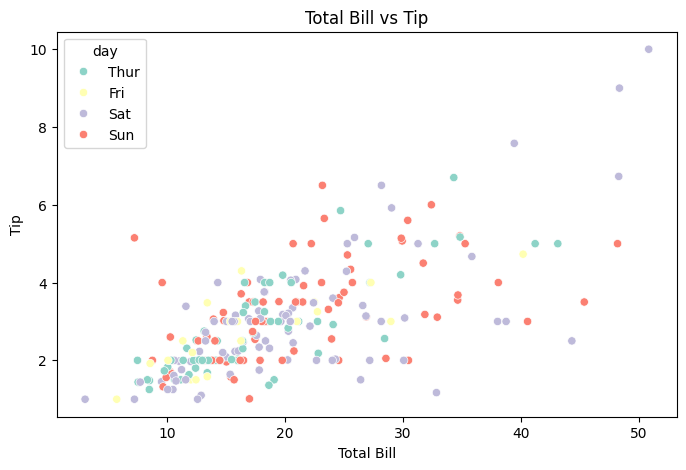

In [60]:
# Q7
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="total_bill", y="tip", hue="day")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Total Bill vs Tip")
plt.show()

/tmp/ipykernel_884/1011967624.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_tip_by_day = df.groupby("day")["tip"].mean().reindex(day_order)


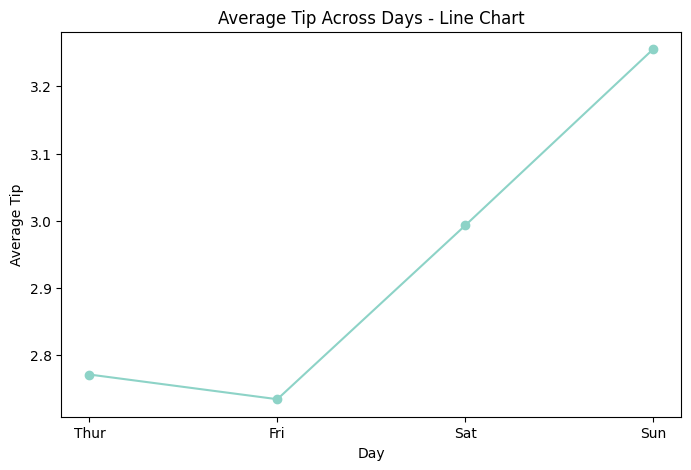

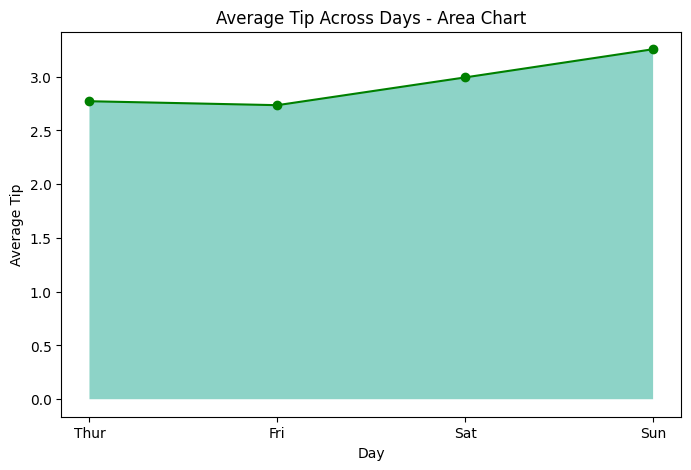

In [68]:
# Q8
day_order = ["Thur", "Fri", "Sat", "Sun"]
avg_tip_by_day = df.groupby("day")["tip"].mean().reindex(day_order)

plt.figure(figsize=(8, 5))
plt.plot(avg_tip_by_day.index, avg_tip_by_day.values, marker="o")
plt.xlabel("Day")
plt.ylabel("Average Tip")
plt.title("Average Tip Across Days - Line Chart")
plt.show()

plt.figure(figsize=(8, 5))
plt.fill_between(avg_tip_by_day.index, avg_tip_by_day.values)
plt.plot(avg_tip_by_day.index, avg_tip_by_day.values, marker="o",color = "green")
plt.xlabel("Day")
plt.ylabel("Average Tip")
plt.title("Average Tip Across Days - Area Chart")
plt.show()

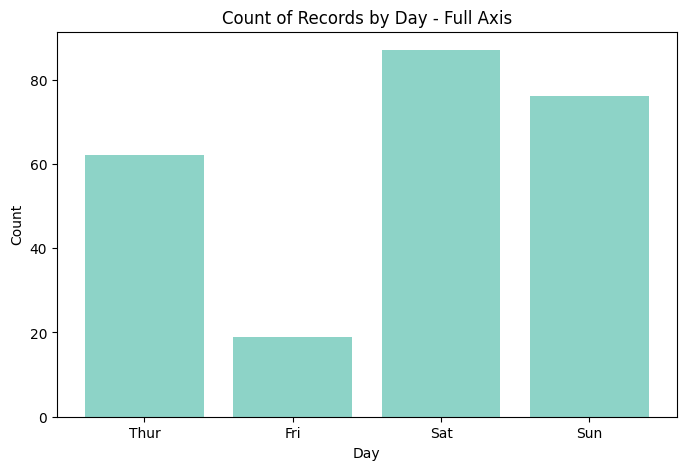

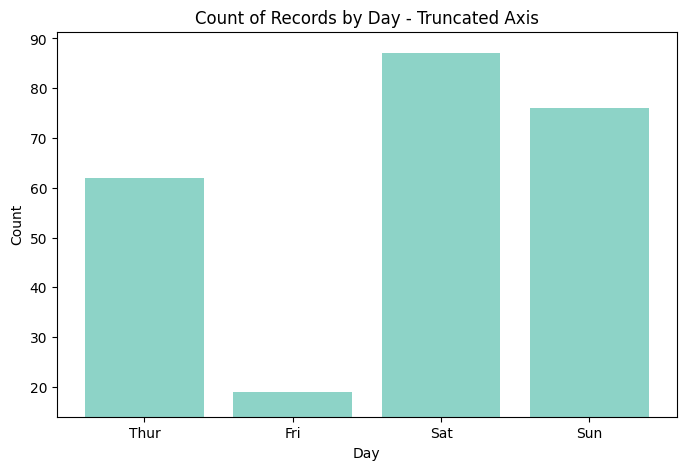

In [62]:
# Q9
counts = df["day"].value_counts().reindex(day_order)

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values)
plt.xlabel("Day")
plt.ylabel("Count")
plt.title("Count of Records by Day - Full Axis")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(counts.index, counts.values)
plt.ylim(bottom=counts.values.min() - 5)
plt.xlabel("Day")
plt.ylabel("Count")
plt.title("Count of Records by Day - Truncated Axis")
plt.show()